# 🧠 Modelo 10: ResNet50 + Data Augmentation - Multi-Seed Analysis

En este notebook entrenamos **ResNet50 con Data Augmentation** usando **5 semillas diferentes** para evaluar la robustez y variabilidad del modelo. Cada entrenamiento corre 100 épocas completas, visualizamos cada curva por separado y calculamos la media ± desviación estándar de las métricas finales.

---

## 0. Configuración Inicial e Imports

In [1]:
import os
import sys

# ⚠️ IMPORTANTE: Estas líneas DEBEN ir ANTES de importar TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime todos los mensajes (INFO, WARNING, ERROR)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Desactiva mensajes de oneDNN
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers

# Suprimir warnings de TensorFlow adicionales
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_resnet50_unfrozen as resnet_model

print("✅ Librerías e importaciones listas")

✅ Librerías e importaciones listas


In [2]:
# Configurar GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No se detectó GPU. Se usará la CPU.")

GPU detectada(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Función para establecer semillas (reproducibilidad)
def set_seeds(seed):
    """Configura todas las semillas aleatorias para reproducibilidad."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

## 1. Carga de Datos (RGB para ResNet50)

**IMPORTANTE**: ResNet50 está diseñado para imágenes en color (3 canales). Cargamos los datos UNA SOLA VEZ y luego aplicaremos augmentation en el loop.

In [4]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración del DataLoader
IMG_SIZE = (224, 224)
BATCH_SIZE = 256
SUBSET = 1

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',  # <--- OBLIGATORIO para ResNet50
    train_subset_fraction=SUBSET,
    optimize=False
)

print(f"✅ Dataset cargado. Clases: {class_names}")

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 256
   • Label mode: int
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.


I0000 00:00:1774869098.888845  818323 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78846 MB memory:  -> device: 0, name: NVIDIA H100 PCIe, pci bus id: 0000:91:00.0, compute capability: 9.0
E0000 00:00:1774869099.018898  818827 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.0.140, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      299 batches
Validation: 86 batches
Test:       43 batches

✅ Dataset cargado. Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


## 2. Entrenamiento Multi-Seed

Entrenamos el modelo con 5 semillas diferentes. Cada entrenamiento:
1. Fija la semilla
2. Crea data augmentation
3. Crea y compila el modelo
4. Entrena 100 épocas
5. Evalúa en test y guarda resultados

In [5]:
# Definar semillas a probar
SEEDS = [42, 123, 456, 789, 999]
EPOCHS = 100
LEARNING_RATE = 1e-5
DROPOUT = 0.4

# Listas para almacenar resultados
histories = []
results_per_seed = []  # [test_loss, test_accuracy] para cada seed
models_seed = []

print(f"Iniciando entrenamiento con {len(SEEDS)} semillas...\n")

Iniciando entrenamiento con 5 semillas...



In [6]:
# Loop sobre semillas
for idx, seed in enumerate(SEEDS, 1):
    print(f"\n{'='*60}")
    print(f"SEED {idx}/{len(SEEDS)}: {seed}")
    print(f"{'='*60}")
    
    # 1. Establecer semilla
    set_seeds(seed)
    
    # 2. Crear data augmentation
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
        layers.RandomBrightness(0.1),
    ], name=f"data_augmentation_seed{seed}")
    
    # 3. Aplicar augmentation al dataset de entrenamiento
    def augment_data(image, label):
        return data_augmentation(image, training=True), label
    
    train_ds_augmented = train_ds.map(
        augment_data,
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)
    
    # 4. Crear modelo
    model = resnet_model.create_resnet_model(
        input_shape=(224, 224, 3),
        num_classes=4,
        dropout_rate=DROPOUT
    )
    
    # 5. Compilar modelo
    model = resnet_model.compile_resnet_model(
        model,
        learning_rate=LEARNING_RATE,
        metrics=['accuracy']
    )
    
    # 6. Crear callbacks personalizados (early stopping por val_accuracy)
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    import tempfile
    
    # Crear directorio temporal para guardar el mejor modelo
    tmp_dir = tempfile.mkdtemp()
    best_model_path = f"{tmp_dir}/best_model_seed{seed}.keras"
    
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=30,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            best_model_path,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            mode='max',
            factor=0.2,
            patience=2,
            min_lr=1e-8,
            verbose=1
        )
    ]
    
    # 7. Entrenar
    print(f"\nEntrenando por {EPOCHS} épocas...")
    history = model.fit(
        train_ds_augmented,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    # 8. Cargar el mejor modelo guardado
    model = tf.keras.models.load_model(best_model_path)
    
    # 9. Evaluar en test
    results = model.evaluate(test_ds, verbose=0)
    test_loss, test_acc = results[0], results[1]
    
    # 10. Guardar resultados
    histories.append(history)
    results_per_seed.append([test_loss, test_acc])
    models_seed.append(model)
    
    print(f"\n✅ Seed {seed} completada:")
    print(f"   - Test Loss:     {test_loss:.4f}")
    print(f"   - Test Accuracy: {test_acc:.4f}")
    print(f"   - Épocas ejecutadas: {len(history.history['loss'])}")


SEED 1/5: 42



Entrenando por 100 épocas...
Epoch 1/100


I0000 00:00:1774869150.101277  818824 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


299/299 ━━━━━━━━━━━━━━━━━━━━ 147s 328ms/step - accuracy: 0.8237 - loss: 0.4895 - val_accuracy: 0.8969 - val_loss: 0.3153 - learning_rate: 1.0000e-05
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 211ms/step - accuracy: 0.9295 - loss: 0.2150 - val_accuracy: 0.9211 - val_loss: 0.2465 - learning_rate: 1.0000e-05
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/step - accuracy: 0.9439 - loss: 0.1721 - val_accuracy: 0.9493 - val_loss: 0.1669 - learning_rate: 1.0000e-05
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/step - accuracy: 0.9519 - loss: 0.1474 - val_accuracy: 0.9540 - val_loss: 0.1421 - learning_rate: 1.0000e-05
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 190ms/step - accuracy: 0.9562 - loss: 0.1343 - val_accuracy: 0.9592 - val_loss: 0.1262 - learning_rate: 1.0000e-05
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 58s 188ms/step - accuracy: 0.9585 - loss: 0.1236 - val_accuracy: 0.9577 - val_loss: 0.1283 - learning_rate: 1.0000e-05
Epoch 7/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/

## 3. Visualización de Curvas por Seed

Mostramos las curvas de entrenamiento y validación para cada semilla de forma separada.

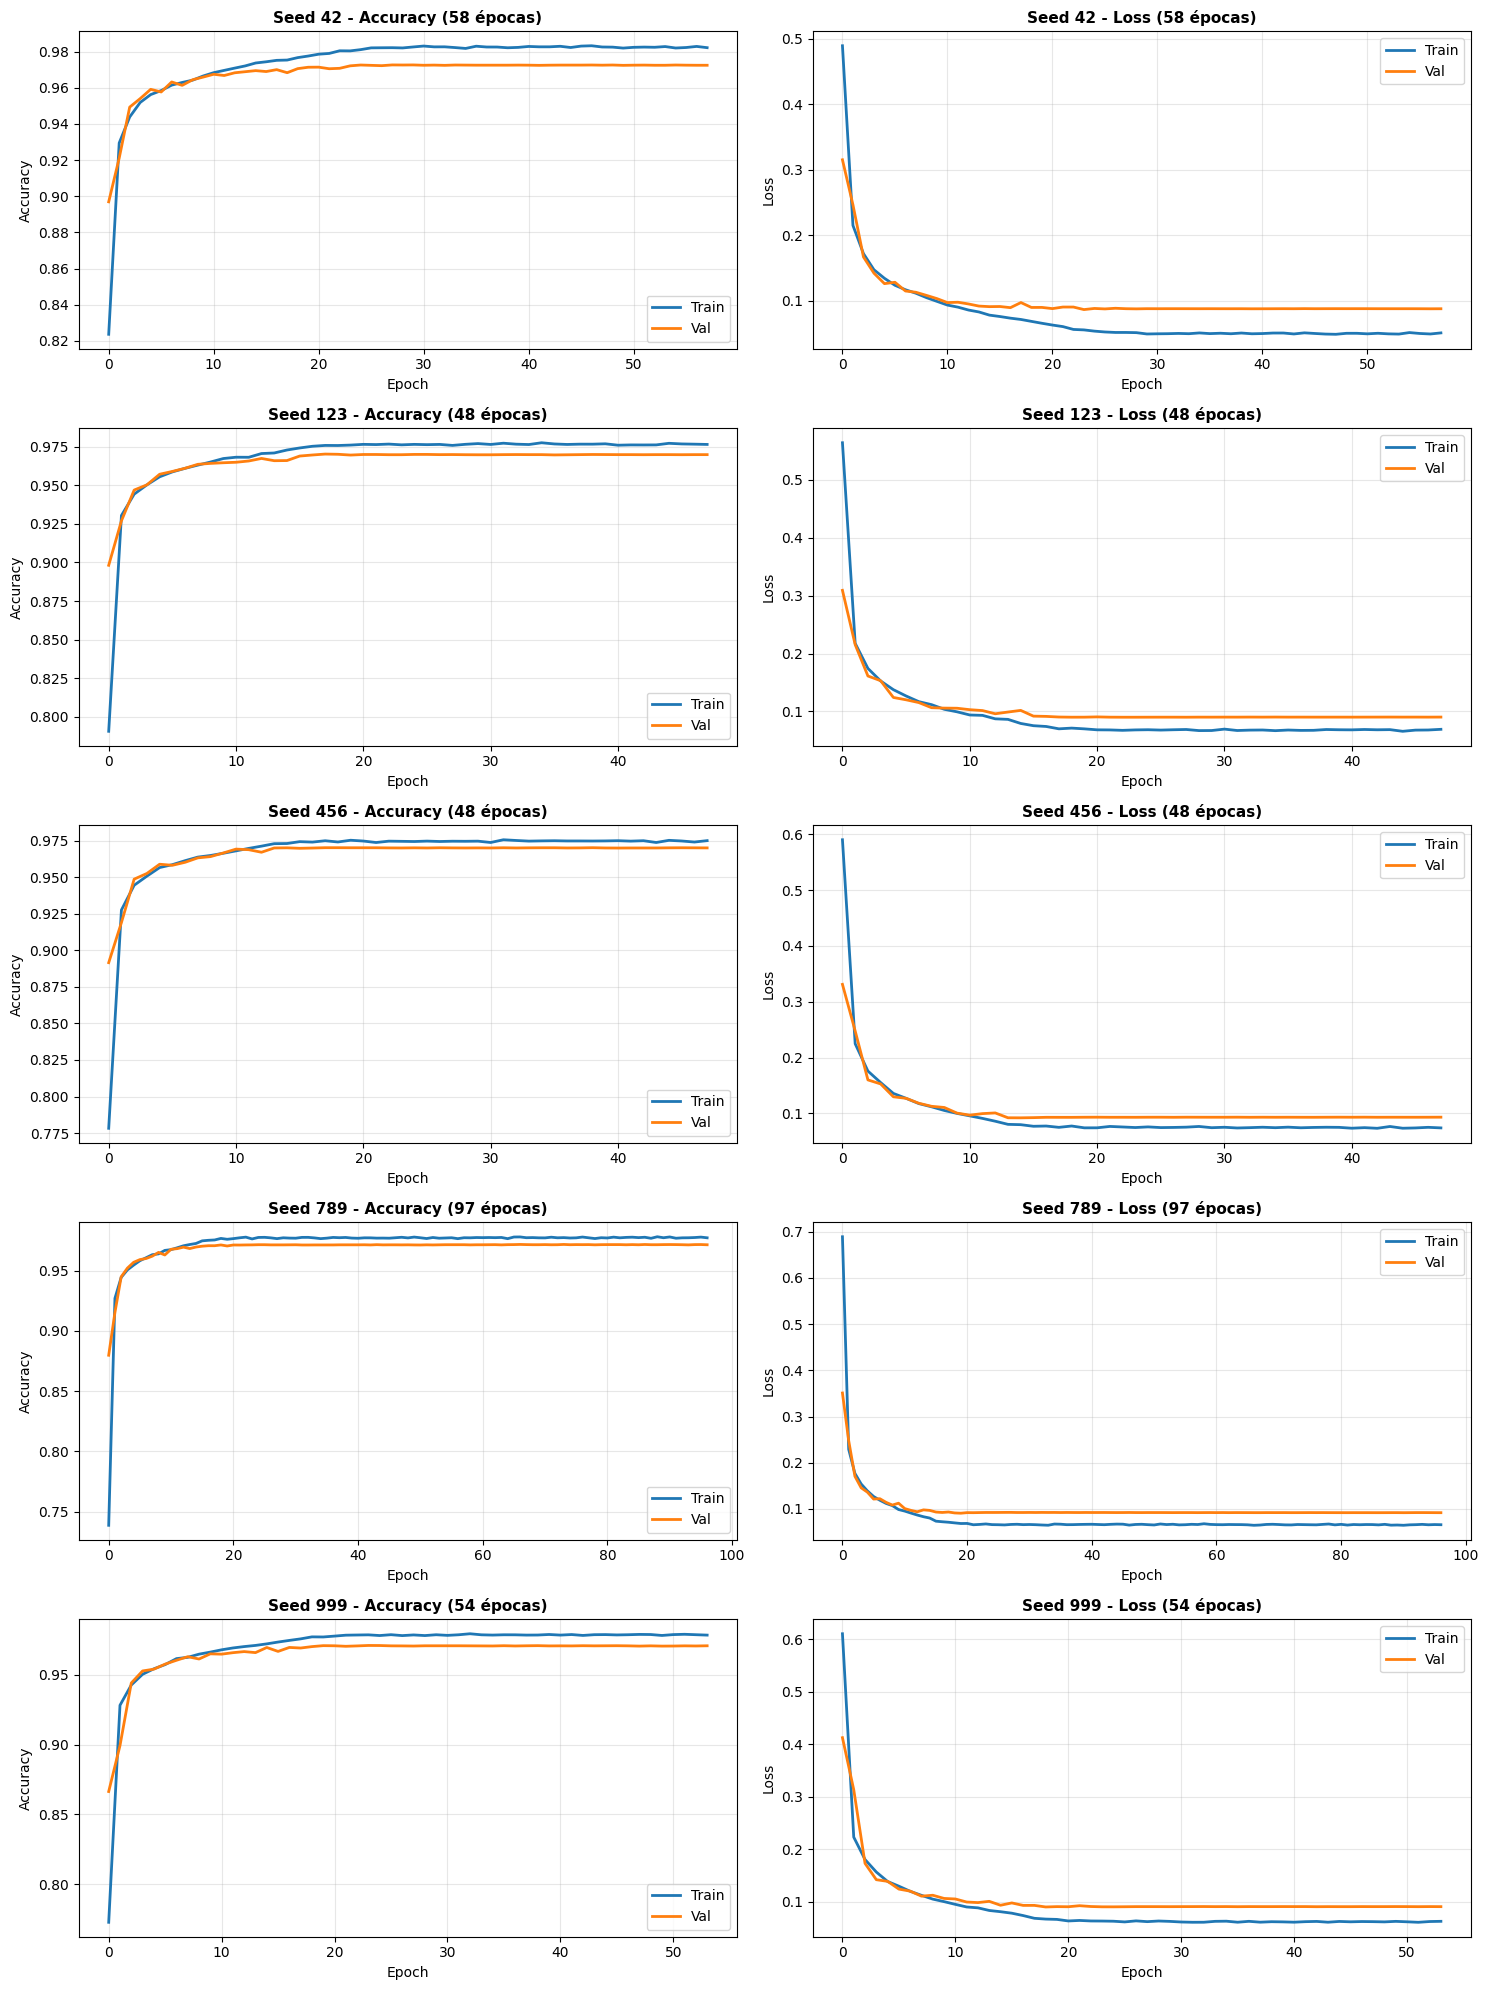

✅ Gráficos de curvas por seed completados


In [7]:
# Gráficos separados para cada seed
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

for idx, (seed, history) in enumerate(zip(SEEDS, histories)):
    # Accuracy
    ax_acc = axes[idx, 0]
    ax_acc.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], label='Val', linewidth=2)
    ax_acc.set_title(f'Seed {seed} - Accuracy ({len(history.history["loss"])} épocas)', fontsize=11, fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)
    
    # Loss
    ax_loss = axes[idx, 1]
    ax_loss.plot(history.history['loss'], label='Train', linewidth=2)
    ax_loss.plot(history.history['val_loss'], label='Val', linewidth=2)
    ax_loss.set_title(f'Seed {seed} - Loss ({len(history.history["loss"])} épocas)', fontsize=11, fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos de curvas por seed completados")

## 4. Visualización Superpuesta (Todas las Seeds)

Gráfico consolidado con todas las semillas superpuestas para comparación visual.

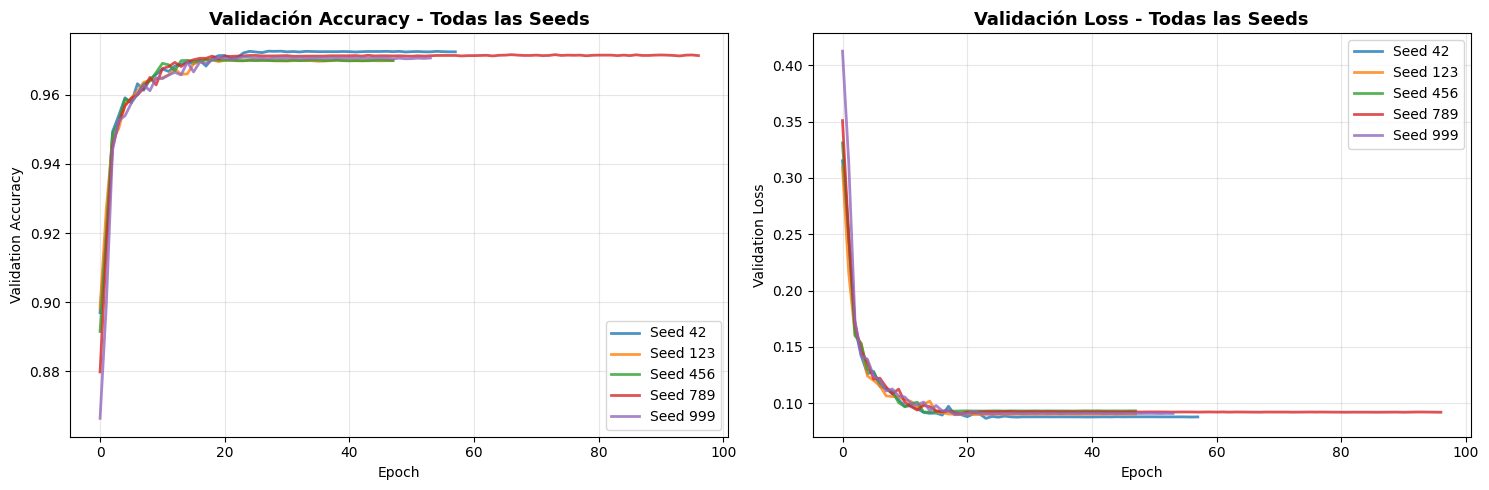

✅ Gráficos superpuestos completados


In [8]:
# Colores para cada seed
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy superpuesto
for seed, history, color in zip(SEEDS, histories, colors):
    ax1.plot(history.history['val_accuracy'], label=f'Seed {seed}', linewidth=2, color=color, alpha=0.8)

ax1.set_title('Validación Accuracy - Todas las Seeds', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Loss superpuesto
for seed, history, color in zip(SEEDS, histories, colors):
    ax2.plot(history.history['val_loss'], label=f'Seed {seed}', linewidth=2, color=color, alpha=0.8)

ax2.set_title('Validación Loss - Todas las Seeds', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos superpuestos completados")

## 5. Resumen Estadístico Final

Cálculo de media y desviación estándar para los resultados de las 5 semillas.

In [9]:
# Convertir resultados a array numpy
results_array = np.array(results_per_seed)

# Calcular estadísticas
test_loss_values = results_array[:, 0]
test_acc_values = results_array[:, 1]

mean_loss = test_loss_values.mean()
std_loss = test_loss_values.std()
mean_acc = test_acc_values.mean()
std_acc = test_acc_values.std()

print("\n" + "="*70)
print("RESUMEN FINAL - MÉTRICAS EN TEST (5 SEMILLAS)")
print("="*70)
print(f"\nResultados individuales por seed:")
for seed, (loss, acc) in zip(SEEDS, results_per_seed):
    print(f"  Seed {seed:3d}: Loss = {loss:.4f}  |  Accuracy = {acc:.4f}")

print(f"\n{'-'*70}")
print(f"MEDIA Y DESVIACIÓN ESTÁNDAR:")
print(f"{'-'*70}")
print(f"Test Loss:     {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Test Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"\nCoeficiente de Variación:")
print(f"  Loss CV:     {(std_loss / mean_loss * 100):.2f}%")
print(f"  Accuracy CV: {(std_acc / mean_acc * 100):.2f}%")
print("="*70)


RESUMEN FINAL - MÉTRICAS EN TEST (5 SEMILLAS)

Resultados individuales por seed:
  Seed  42: Loss = 0.0975  |  Accuracy = 0.9712
  Seed 123: Loss = 0.0999  |  Accuracy = 0.9665
  Seed 456: Loss = 0.1059  |  Accuracy = 0.9652
  Seed 789: Loss = 0.1043  |  Accuracy = 0.9660
  Seed 999: Loss = 0.1030  |  Accuracy = 0.9667

----------------------------------------------------------------------
MEDIA Y DESVIACIÓN ESTÁNDAR:
----------------------------------------------------------------------
Test Loss:     0.1021 ± 0.0030
Test Accuracy: 0.9671 ± 0.0021

Coeficiente de Variación:
  Loss CV:     2.96%
  Accuracy CV: 0.22%


## 6. Análisis Detallado del Mejor Modelo

Evaluación adicional del modelo con mejor accuracy en test.


Mejor modelo encontrado:
  Seed: 42
  Test Loss: 0.0975
  Test Accuracy: 0.9712

Generando métricas adicionales...

Reporte de Clasificación (Mejor Modelo - Seed 42):
              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3746
         DME       0.96      0.95      0.96      1161
      DRUSEN       0.86      0.90      0.88       887
      NORMAL       0.99      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.95      0.95      0.95     10933
weighted avg       0.97      0.97      0.97     10933



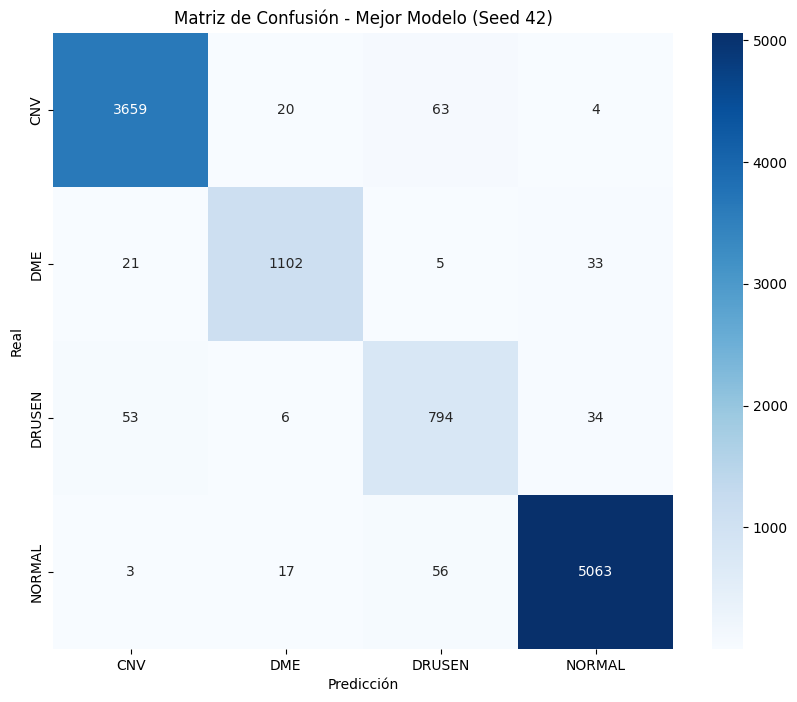

In [10]:
# Encontrar el mejor modelo (por accuracy en test)
best_idx = np.argmax(test_acc_values)
best_seed = SEEDS[best_idx]
best_model = models_seed[best_idx]
best_acc = test_acc_values[best_idx]
best_loss = test_loss_values[best_idx]

print(f"\nMejor modelo encontrado:")
print(f"  Seed: {best_seed}")
print(f"  Test Loss: {best_loss:.4f}")
print(f"  Test Accuracy: {best_acc:.4f}")
print(f"\nGenerando métricas adicionales...\n")

# Obtener predicciones del mejor modelo
y_true = []
y_probs = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = best_model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Reporte de clasificación
print(f"Reporte de Clasificación (Mejor Modelo - Seed {best_seed}):")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión - Mejor Modelo (Seed {best_seed})')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()